#**Week 5 Day 3**

1.	Feature selection: SelectKBest (chi2, f_classif), RFE, permutation importance
2.	Drop correlated features: compute correlation matrix, remove one of any pair >0.95
3.	Class imbalance: SMOTE oversampling — compare F1 before/after on an imbalanced dataset


In [118]:
import pandas as pd
import numpy as np

In [119]:
#from google.colab import drive
#drive.mount('/content/drive')

In [120]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Roadmap/Datasets/titanic/train.csv")

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [122]:
df = df.drop(columns=['Cabin'])

#1. Fill Age nulls with median
df['Age'] = df['Age'].fillna(df['Age'].median())

In [123]:
# 2. Encode Sex as 0/1

df['Sex_encoded'] = df['Sex'].map({'male':0,'female':1})

In [124]:
#drop null rows
df = df.dropna()

In [125]:
X = df[['Pclass', 'Age', 'Fare', 'Sex_encoded']]
y = df['Survived']

###Task 1  
1. SelectKBest On Titanic, use SelectKBest with f_classif to select top 3 features from your feature set.
2. Print scores for each feature.




### SelectKBest :
1. Looks at each feature individually : Scores each feature alone
2. Would score both Pclass and Fare highly and keep both together, even though they are redundant  

In [126]:
from sklearn.feature_selection import SelectKBest, f_classif

kBest = SelectKBest(k=3).fit(X,y)

#Score per feature
for features, score in zip(X.columns, kBest.scores_):
  print(f"{features} : {score:.2f}")

Pclass : 112.54
Age : 4.35
Fare : 61.84
Sex_encoded : 368.15


1. Sex was the strongest survival predictor (women first), then Pclass and Fare

2. Age had weak relationship directly with Survival


3. Sex_encoded 0/1 is male v/s female
      - Survival rate of 74% women, 19% male

- f_classif measures the statistical relationship between each feature and the target using ANOVA F-test.
    - F-score measures how much the target(Survival) varies between the groups of that feature.
    - Sex creates two distinct groups with different survival rates, thats a huge variance difference, hence the high score of 368

4. - High F-score = feature creates clearly separated groups in the target.
   -  Low F-score = feature doesn't separate groups well.

### Task 2
1. RFE Use RFE with RandomForestClassifier to select top 3 features.
2. Compare which features it picks vs SelectKBest


In [127]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

#Rfe needs a model to evaluate features
model = RandomForestClassifier(random_state=42)


rfe = RFE(estimator=model, n_features_to_select=3)
rfe.fit(X,y)


for feature,selected in zip(X.columns,rfe.support_):
  print(f"{feature} : {selected}")


Pclass : False
Age : True
Fare : True
Sex_encoded : True


## SelectKBest v/s RFE
1. SelectKBest scored Age low(weak alone)
2. RFE kept Age(adds value in combination)
3. SelectKBest Scored Pclass higher, RFE dropped it (Redudant)

#### RFE captures feature interactions, SelectKBest does not

### Task 3

1. Permutation Importance Use permutation_importance on a trained RandomForest
2. Compare ranking to Task 1 and 2.


In [128]:
from sklearn.inspection import permutation_importance

rf = RandomForestClassifier(random_state=42)
rf.fit(X,y)

#permutation importance
result  = permutation_importance(rf, X, y, n_repeats=10, random_state=42)

for features, importance in zip(X.columns, result.importances_mean):
  print(f"{features} : {importance:.2f}")

Pclass : 0.20
Age : 0.18
Fare : 0.19
Sex_encoded : 0.25


## Feature Selection Comparison

| Feature | SelectKBest | RFE | Permutation |
|---------|-------------|-----|-------------|
| Sex_encoded | 1st | kept | 1st |
| Pclass | 2nd | dropped | 3rd |
| Fare | 3rd | kept | 2nd |
| Age | 4th | kept | 4th |

#### Key insight: SelectKBest dropped Age (weak alone, score=4.35) but
- RFE and Permutation both kept it
- it contributes 0.18 in combination
with other features. SelectKBest misses feature interactions.

### Task 4
1. Drop correlated features On House Prices, compute correlation matrix, find any pairs >0.95, drop one from each pair.
2. Does RMSE improve?


In [129]:
df_housing = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Roadmap/Datasets/Housing Price/train.csv")

In [130]:
df_housing = pd.get_dummies(df_housing)

In [131]:
X_housing = df_housing.drop(columns='SalePrice')
y_housing = df_housing['SalePrice']

In [132]:
corr_matrix = df_housing.select_dtypes(include = 'number').corr()
corr_matrix

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


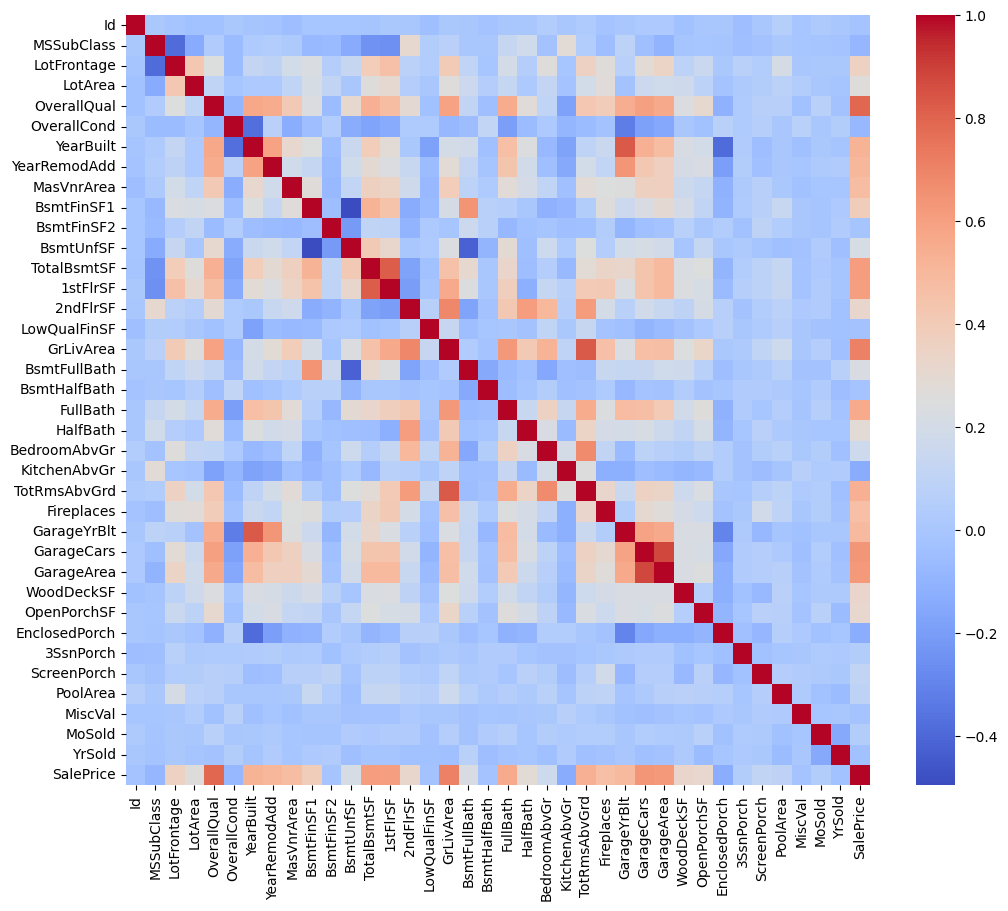

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.show()

In [134]:
#upper traingle- avoiding duplicates
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
upper

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,NaN,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,NaN,NaN,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,NaN,NaN,NaN,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,NaN,NaN,NaN,NaN,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,NaN,NaN,NaN,NaN,NaN,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,NaN,NaN,NaN,NaN,NaN,NaN,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


In [135]:
# correlation >0.95
high_corr = [(col, row) for col in upper.columns
             for row in upper.index
             if abs(upper[col][row]) > 0.80]

print(high_corr)

[('1stFlrSF', 'TotalBsmtSF'), ('TotRmsAbvGrd', 'GrLivArea'), ('GarageYrBlt', 'YearBuilt'), ('GarageArea', 'GarageCars')]


- four highly correlated pairs at 0.80 threshold:

1. 1stFlrSF ↔ TotalBsmtSF : first floor size correlates with basement size
2. TotRmsAbvGrd ↔ GrLivArea : total rooms correlates with living area
3. GarageYrBlt ↔ YearBuilt : garage built same year as house
4. GarageArea ↔ GarageCars : bigger garage fits more cars

In [136]:
df_housing = df_housing.drop(columns=['TotalBsmtSF', 'GrLivArea', 'GarageYrBlt', 'GarageCars'])

In [138]:
#Running XGBoost after dropping redundant columns
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

xgb = XGBRegressor(n_estimators = 417, max_depth = 3, learning_rate =0.135)


scores = cross_val_score(xgb, X_housing, y_housing, cv= 5, scoring='neg_mean_squared_error')
print(np.mean(scores))

-736584288.0


In [139]:
print(f"RMSE: {np.sqrt(abs(np.mean(scores))):,.0f}")

RMSE: 27,140



## Correlation-based Feature Selection

Pairs with correlation > 0.80:
- 1stFlrSF ↔ TotalBsmtSF
- TotRmsAbvGrd ↔ GrLivArea  
- GarageYrBlt ↔ YearBuilt
- GarageArea ↔ GarageCars

No pairs above 0.95 threshold.

1. Dropping one from each pair: RMSE \$27,140 vs baseline \$26,000 : worse.
2. Tree models handle correlated features well, they naturally select
the more useful one at each split.
3. Dropping correlated features helps linear models more than tree models.

Rule:
1. For tree models, only drop features correlated >0.95.
2. For linear models, drop >0.80.

### Task 5
1.SMOTE: Find or create an imbalanced dataset, train RandomForest, compare F1 score before and after SMOTE oversampling.

--------------------------------------------

#### tHEORY:
-- Imbalanced dataset with 90% class 1 and 10% class 2
 1. to tackle this
 - UnderSampling: cut class 1 rows until balanced
 - OverSampling: add class 2 rows until balanced


-- Smote is an overSampling technique
1. It is used to fill the under represented class with k nearest neighbours.
2. Find the nearest neighbours and creates synthetic samples

In [140]:
from imblearn.over_sampling import SMOTE

In [143]:
#Titanic is actually slightly imbalanced (62% died, 38% survived)

# 1.Train RandomForest, print F1 score before SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(random_state=42)
scores = cross_val_score(rf, X, y, cv=5, scoring='f1')
print(f"F1 before SMOTE: {np.mean(scores):.3f}")

F1 before SMOTE: 0.750


In [144]:
#2. Apply SMOTE to X and y
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state= 42)
X_resampled, y_resampled = sm.fit_resample(X, y)



print(f"Before SMOTE: {y.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_resampled).value_counts().to_dict()}")

Before SMOTE: {0: 549, 1: 340}
After SMOTE: {0: 549, 1: 549}


In [146]:
scores_ =  cross_val_score(rf, X_resampled, y_resampled, cv=5, scoring = 'f1')
print(f"F1 after SWOTE: {np.mean(scores_):.3f}")

F1 after SWOTE: 0.816


#### 0.816 vs 0.750 :solid improvement from SMOTE

### Task 6  
- use OF each feature selection method?

## Feature Selection & Class Imbalance

### Feature Selection Methods
- SelectKBest:
1. Scores each feature independently using statistical test
  (f_classif for classification).
2.  Fast but misses feature interactions dropped Age despite it contributing 0.18 in combination with other features.
- RFE:
1. Trains model repeatedly, removes weakest feature each round.
2. Captures feature interactions: kept Age, dropped Pclass (redundant with Fare).
- Permutation Importance:
1. Shuffles one feature at a time, measures score drop.
  Best for explaining a trained model.
  2.  Confirmed Sex_encoded most important (0.25).

### Correlation-based Dropping
- Drop when corr > 0.95 for tree models : they handle lower correlation naturally.
- Drop when corr > 0.80 for linear models : more sensitive to multicollinearity.
- Always validate empirically: dropping 0.80 pairs hurt House Prices RMSE
  ($27,140 vs $26,000 baseline).
-  Correlated features can still carry unique signal.


### SMOTE
- Synthetic Minority Oversampling Technique.
- Creates synthetic minority class samples by interpolating between existing minority examples and their K nearest neighbours. More realistic than simple duplication.
- Improved Titanic F1: 0.750 -> 0.816.
- Use F1 over accuracy when classes are imbalanced, a model predicting
  majority class always gets high accuracy but F1 = 0.